In [0]:
import os
import sys
from uuid import uuid4

import boto3
import pandas as pd

from arcgis.geocoding import geocode
from arcgis.geometry import Geometry, MultiPoint
from arcgis.geometry.filters import intersects
from arcgis.gis import GIS, ItemProperties, ItemTypeEnum

from arcgis.raster import utils as raster_utils
from arcgis.raster import ImageryLayer
from arcgis.raster.functions import band_arithmetic

In [0]:
# If you are using a guest account for the hackathon you can connect to the
# CSU ArcGIS Online org it is as simple as passing in the assigned guest
# username and password:
gis = GIS('https://csurams.maps.arcgis.com', 'csuguest10', 'CSUguest10!')

# prove I'm connected
me = gis.users.me
print(me.username)

csuguest10


In [0]:
# use get() when you know the ID of an existing item

# Grab the USDA NAIP Color Infrared Imagery from the Living Atlas
international_segment_feature_layer = gis.content.get('ffc2e851a5fd4ef7a1e2581072b5c46d')
print(f'{international_segment_feature_layer.title}, is a {international_segment_feature_layer.type}')

PPQ International Segments Feature Layer, is a Feature Service


In [0]:
# Get the actual layer from the item
layer = international_segment_feature_layer.layers[0]

# Pull data into a pandas dataframe
international_df = layer.query(
    where="1=1",
    out_fields="*",
    as_df=True
)

# See how much data you have
print(f"Total records: {len(international_df)}")
print(f"Columns available: {international_df.columns.tolist()}")

# Preview the data
display(international_df.head(10))

Total records: 544082
Columns available: ['OBJECTID', 'DEPARTURES_SCHEDULED', 'DEPARTURES_PERFORMED', 'PAYLOAD', 'SEATS', 'PASSENGERS', 'FREIGHT', 'MAIL', 'DISTANCE', 'RAMP_TO_RAMP', 'AIR_TIME', 'UNIQUE_CARRIER', 'AIRLINE_ID', 'UNIQUE_CARRIER_NAME', 'UNIQUE_CARRIER_ENTITY', 'REGION', 'CARRIER', 'CARRIER_NAME', 'CARRIER_GROUP', 'CARRIER_GROUP_NEW', 'ORIGIN_AIRPORT_ID', 'ORIGIN_AIRPORT_SEQ_ID', 'ORIGIN_CITY_MARKET_ID', 'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_COUNTRY', 'ORIGIN_COUNTRY_NAME', 'ORIGIN_WAC', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_AIRPORT_ID', 'DEST_AIRPORT_SEQ_ID', 'DEST_CITY_MARKET_ID', 'DEST', 'DEST_CITY_NAME', 'DEST_COUNTRY', 'DEST_COUNTRY_NAME', 'DEST_WAC', 'DEST_LAT', 'DEST_LON', 'AIRCRAFT_GROUP', 'AIRCRAFT_TYPE', 'AIRCRAFT_CONFIG', 'YEAR_WADS', 'QUARTER_WADS', 'MONTH_WADS', 'DISTANCE_GROUP', 'CLASS', 'SHAPE']


,OBJECTID,DEPARTURES_SCHEDULED,DEPARTURES_PERFORMED,PAYLOAD,SEATS,PASSENGERS,FREIGHT,MAIL,DISTANCE,RAMP_TO_RAMP,AIR_TIME,UNIQUE_CARRIER,AIRLINE_ID,UNIQUE_CARRIER_NAME,UNIQUE_CARRIER_ENTITY,REGION,CARRIER,CARRIER_NAME,CARRIER_GROUP,CARRIER_GROUP_NEW,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_COUNTRY,ORIGIN_COUNTRY_NAME,ORIGIN_WAC,ORIGIN_LAT,ORIGIN_LON,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,DEST,DEST_CITY_NAME,DEST_COUNTRY,DEST_COUNTRY_NAME,DEST_WAC,DEST_LAT,DEST_LON,AIRCRAFT_GROUP,AIRCRAFT_TYPE,AIRCRAFT_CONFIG,YEAR_WADS,QUARTER_WADS,MONTH_WADS,DISTANCE_GROUP,CLASS,SHAPE
0,401,13,13,534000,2094,1439,0,0,1582,3056,2716,B6,20409,JetBlue Airways,16673,L,B6,JetBlue Airways,3,3,10721,1072102,30721,BOS,"Boston, MA",US,United States,13,42.35866,-71.05674,15013,1501302,35013,STI,"Santiago, Dominican Republic",DO,Dominican Republic,224,19.45404,-70.70745,6,694,1,2022,1,2,4,F,"{""x"": 1909432.8728, ""y"": 531173.3172999993, ""s..."
1,402,15,14,726600,2800,2121,0,0,1582,3135,2759,B6,20409,JetBlue Airways,16673,L,B6,JetBlue Airways,3,3,10721,1072102,30721,BOS,"Boston, MA",US,United States,13,42.35866,-71.05674,15013,1501302,35013,STI,"Santiago, Dominican Republic",DO,Dominican Republic,224,19.45404,-70.70745,6,699,1,2022,1,2,4,F,"{""x"": 1909432.8728, ""y"": 531173.3172999993, ""s..."
2,403,0,23,1169315,4282,2810,440,0,2395,0,0,S4,20360,Sata Internacional,9469D,I,S4,Sata Internacional,0,0,10721,1072102,30721,BOS,"Boston, MA",US,United States,13,42.35866,-71.05674,14051,1405107,34051,PDL,"Ponta Delgada, Portugal",PT,Portugal,469,37.73962,-25.66855,6,699,1,2020,1,1,5,F,"{""x"": 1909432.8728, ""y"": 531173.3172999993, ""s..."
3,404,0,20,1016796,3728,2762,917,0,2395,0,0,S4,20360,Sata Internacional,9469D,I,S4,Sata Internacional,0,0,10721,1072102,30721,BOS,"Boston, MA",US,United States,13,42.35866,-71.05674,14051,1405107,34051,PDL,"Ponta Delgada, Portugal",PT,Portugal,469,37.73962,-25.66855,6,699,1,2020,1,2,5,F,"{""x"": 1909432.8728, ""y"": 531173.3172999993, ""s..."
4,405,0,13,660917,2418,1328,156,0,2395,0,0,S4,20360,Sata Internacional,9469D,I,S4,Sata Internacional,0,0,10721,1072102,30721,BOS,"Boston, MA",US,United States,13,42.35866,-71.05674,14051,1405107,34051,PDL,"Ponta Delgada, Portugal",PT,Portugal,469,37.73962,-25.66855,6,699,1,2020,1,3,5,F,"{""x"": 1909432.8728, ""y"": 531173.3172999993, ""s..."
5,406,0,5,228800,840,278,0,0,2395,0,0,TP,19576,Tap-Portuguese Airlines,9469A,I,TP,Tap-Portuguese Airlines,0,0,10721,1072102,30721,BOS,"Boston, MA",US,United States,13,42.35866,-71.05674,14051,1405107,34051,PDL,"Ponta Delgada, Portugal",PT,Portugal,469,37.73962,-25.66855,6,824,1,2020,3,7,5,F,"{""x"": 1909432.8728, ""y"": 531173.3172999993, ""s..."
6,407,0,12,610078,2236,865,1109,0,2395,0,0,S4,20360,Sata Internacional,9469D,I,S4,Sata Internacional,0,0,10721,1072102,30721,BOS,"Boston, MA",US,United States,13,42.35866,-71.05674,14051,1405107,34051,PDL,"Ponta Delgada, Portugal",PT,Portugal,469,37.73962,-25.66855,6,699,1,2020,3,7,5,F,"{""x"": 1909432.8728, ""y"": 531173.3172999993, ""s..."
7,408,0,13,660917,2426,510,180,0,2395,0,0,S4,20360,Sata Internacional,9469D,I,S4,Sata Internacional,0,0,10721,1072102,30721,BOS,"Boston, MA",US,United States,13,42.35866,-71.05674,14051,1405107,34051,PDL,"Ponta Delgada, Portugal",PT,Portugal,469,37.73962,-25.66855,6,699,1,2020,3,8,5,F,"{""x"": 1909432.8728, ""y"": 531173.3172999993, ""s..."
8,409,0,13,594880,2182,1180,0,0,2395,0,0,TP,19576,Tap-Portuguese Airlines,9469A,I,TP,Tap-Portuguese Airlines,0,0,10721,1072102,30721,BOS,"Boston, MA",US,United States,13,42.35866,-71.05674,14051,1405107,34051,PDL,"Ponta Delgada, Portugal",PT,Portugal,469,37.73962,-25.66855,6,824,1,2020,3,8,5,F,"{""x"": 1909432.8728, ""y"": 531173.3172999993, ""s..."
9,410,0,13,594880,2184,1168,0,0,2395,0,0,TP,19576,Tap-Portuguese Airlines,9469A,I,TP,Tap-Portuguese Airlines,0,0,10721,1072102,30721,BOS,"Boston, MA",US,United States,13,42.35866,-71.05674,14051,1405107,34051,PDL,"Ponta

In [0]:
# Search for fruit fly related content
results = gis.content.search(
    query='fruit fly PPQ',
    max_items=20,
    outside_org=True
)

for item in results:
    print(f"{item.title} | {item.type} | ID: {item.id}")

PPQ Fruit Fly Image | Image | ID: 4852c12beb9046d7add62d275d901fdb
PPQ TX Quarantine Areas Feature Layer | Feature Service | ID: b0b5666860f34ab2b4a27f4dff35597b
PPQ Fruit Fly Detections Summary Feature Layer | Feature Service | ID: 24ed5194234f4d0a824430b745b2b8f4
PPQ MEDFF Small Image | Image | ID: ae8737ba5ea047aa9f196222288c24ee


In [0]:
# Replace ID_HERE with what comes back from search
domestic_segments = gis.content.get('f2d35d3da8644c0ca4b7b6ac2c1486f6')
print(f'{domestic_segments.title}, is a {domestic_segments.type}')

PPQ Domestic Segments Feature Layer, is a Feature Service


In [0]:
domestic_layer = domestic_segments.layers[0]

# domestic_df = domestic_layer.query(
#     where="1=1",
#     out_fields="*",
#     as_df=True
# )

# print(f"Total records: {len(domestic_df)}")
# print(f"Columns: {domestic_df.columns.tolist()}")
# display(domestic_df.head(10))

# Just get 100 rows to see structure
# domestic_df = domestic_layer.query(
#     where="1=1",
#     out_fields="*",
#     as_df=True,
#     result_record_count=100
# )

# Filter WHILE loading from ArcGIS
# Much more efficient!
domestic_df = domestic_layer.query(
    where="DEST_STATE_NM IN ('California', 'Texas', 'Florida')",
    out_fields="*",
    as_df=True
)

print(f"Total filtered records: {len(domestic_df)}")
display(domestic_df.head(10))

# print(f"Columns: {domestic_df.columns.tolist()}")
# display(domestic_df.head(5))

Total filtered records: 608918


,OBJECTID,DEPARTURES_SCHEDULED,DEPARTURES_PERFORMED,PAYLOAD,SEATS,PASSENGERS,FREIGHT,MAIL,DISTANCE,RAMP_TO_RAMP,AIR_TIME,UNIQUE_CARRIER,AIRLINE_ID,UNIQUE_CARRIER_NAME,UNIQUE_CARRIER_ENTITY,REGION,CARRIER,CARRIER_NAME,CARRIER_GROUP,CARRIER_GROUP_NEW,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,ORIGIN_STATE_FIPS,ORIGIN_STATE_NM,ORIGIN_WAC,ORIGIN_LAT,ORIGIN_LON,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,DEST,DEST_CITY_NAME,DEST_STATE_ABR,DEST_STATE_FIPS,DEST_STATE_NM,DEST_WAC,DEST_LAT,DEST_LON,AIRCRAFT_GROUP,AIRCRAFT_TYPE,AIRCRAFT_CONFIG,YEAR_BTS,QUARTER_BTS,MONTH_BTS,DISTANCE_GROUP,CLASS,SHAPE
0,548,10,10,353887,1660,1019,2382,0,3266,4124,3876,UA,19977,United Air Lines Inc.,0A875,D,UA,United Air Lines Inc.,3,3,10299,1029906,30299,ANC,"Anchorage, AK",AK,2,Alaska,1,61.21753,-149.85815,12266,1226603,31453,IAH,"Houston, TX",TX,48,Texas,74,29.76078,-95.36952,6,838,1,2025,2,5,7,F,"{""x"": -2773630.3121000007, ""y"": 3274769.583900..."
1,547,0,1,273300,0,0,212071,0,3266,390,351,WI,20195,Sky Lease Cargo,16884,I,WI,Sky Lease Cargo,2,2,10299,1029906,30299,ANC,"Anchorage, AK",AK,2,Alaska,1,61.21753,-149.85815,12266,1226603,31453,IAH,"Houston, TX",TX,48,Texas,74,29.76078,-95.36952,8,820,2,2025,2,4,7,P,"{""x"": -2773630.3121000007, ""y"": 3274769.583900..."
2,520,0,1,157333,453,0,8417,0,3266,351,336,5Y,20007,Atlas Air Inc.,06087,D,5Y,Atlas Air Inc.,3,3,10299,1029906,30299,ANC,"Anchorage, AK",AK,2,Alaska,1,61.21753,-149.85815,12266,1226603,31453,IAH,"Houston, TX",TX,48,Texas,74,29.76078,-95.36952,8,819,2,2024,4,12,7,L,"{""x"": -2773630.3121000007, ""y"": 3274769.583900..."
3,519,0,1,245489,0,0,238791,0,3266,468,420,5Y,20007,Atlas Air Inc.,06087,D,5Y,Atlas Air Inc.,3,3,10299,1029906,30299,ANC,"Anchorage, AK",AK,2,Alaska,1,61.21753,-149.85815,12266,1226603,31453,IAH,"Houston, TX",TX,48,Texas,74,29.76078,-95.36952,8,819,1,2024,4,12,7,P,"{""x"": -2773630.3121000007, ""y"": 3274769.583900..."
4,518,0,1,224872,0,0,104629,0,3266,446,400,5Y,20007,Atlas Air Inc.,6087,D,5Y,Atlas Air Inc.,3,3,10299,1029906,30299,ANC,"Anchorage, AK",AK,2,Alaska,1,61.21753,-149.85815,12266,1226603,31453,IAH,"Houston, TX",TX,48,Texas,74,29.76078,-95.36952,6,627,1,2024,4,11,7,P,"{""x"": -2773630.3121000007, ""y"": 3274769.583900..."
5,517,0,1,268400,0,0,247535,0,3266,0,0,CX,19779,Cathay Pacific Airways Ltd.,9729A,I,CX,Cathay Pacific Airways Ltd.,0,0,10299,1029906,30299,ANC,"Anchorage, AK",AK,2,Alaska,1,61.21753,-149.85815,12266,1226603,31453,IAH,"Houston, TX",TX,48,Texas,74,29.76078,-95.36952,8,821,2,2024,4,11,7,G,"{""x"": -2773630.3121000007, ""y"": 3274769.583900..."
6,516,0,1,480900,0,0,0,0,3266,484,443,KAQ,20370,Kalitta Air LLC,6683,D,KAQ,Kalitta Air LLC,3,3,10299,1029906,30299,ANC,"Anchorage, AK",AK,2,Alaska,1,61.21753,-149.85815,12266,1226603,31453,IAH,"Houston, TX",TX,48,Texas,74,29.76078,-95.36952,8,819,2,2024,4,11,7,P,"{""x"": -2773630.3121000007, ""y"": 3274769.583900..."
7,515,0,1,264000,0,0,112620,0,3266,0,0,ADB,20110,Antonov Company,9488B,I,ADB,Antonov Company,0,0,10299,1029906,30299,ANC,"Anchorage, AK",AK,2,Alaska,1,61.21753,-149.85815,12266,1226603,31453,IAH,"Houston, TX",TX,48,Texas,74,29.76078,-95.36952,8,880,2,2024,4,10,7,P,"{""x"": -2773630.3121000007, ""y"": 3274769.583900..."
8,514,0,1,232018,0,0,207713,0,3266,458,431,FX,20107,Federal Express Corporation,6200,D,FX,Federal Express Corporation,3,3,10299,1029906,30299,ANC,"Anchorage, AK",AK,2,Alaska,1,61.21753,-149.85815,12266,1226603,31453,IAH,"Houston, TX",TX,48,Texas,74,29.76078,-95.36952,6,683,2,2024,4,10,7,P,"{""x"": -2773630.3121000007, ""y"": 3274769.583900..."
9,513,0,1,480900,0,0,236527,0,3266,442,417,KAQ,20370,Kalitta Air LLC,6683,D,KAQ,Kalitta Air LLC,3,3,10299,1029906,30299,ANC,"Anchorage, AK",AK,2,Alaska,1,61.21753,-149.85815,12266,1226603,31453,IAH,"Houston, TX",TX,48,Texas,74,29.76078,-95.36952,8,819,2,2024,4,10,7,P,"{""x"": -2773630.3121000007, ""y"": 3274769.583900..."


In [0]:
# Replace ID_HERE with what comes back from search
fruit_fly_detection_summary = gis.content.get('24ed5194234f4d0a824430b745b2b8f4')
print(f'{fruit_fly_detection_summary.title}, is a {fruit_fly_detection_summary.type}')

PPQ Fruit Fly Detections Summary Feature Layer, is a Feature Service


In [0]:
fruit_fly_layer = fruit_fly_detection_summary.layers[0]

fruit_fly_df = fruit_fly_layer.query(
    where="1=1",
    out_fields="*",
    as_df=True
)

print(f"Total records: {len(fruit_fly_df)}")
print(f"Columns: {fruit_fly_df.columns.tolist()}")
display(fruit_fly_df.head(20))


Total records: 305
Columns: ['OBJECTID', 'NAME', 'STATE_NAME', 'monthyear', 'CommonName', 'Count_', 'Shape__Area', 'Shape__Length', 'SHAPE']


,OBJECTID,NAME,STATE_NAME,monthyear,CommonName,Count_,Shape__Area,Shape__Length,SHAPE
0,1,Cameron County,Texas,01/2025,Mexican Fruit Fly,13.0,2439115116.406128,939031.574311,"{""rings"": [[[-119012.8452, -1626525.7954], [-1..."
1,2,Cameron County,Texas,02/2022,Mexican Fruit Fly,10.0,2439115116.406128,939031.574311,"{""rings"": [[[-119012.8452, -1626525.7954], [-1..."
2,3,Cameron County,Texas,02/2024,Mexican Fruit Fly,2.0,2439115116.406128,939031.574311,"{""rings"": [[[-119012.8452, -1626525.7954], [-1..."
3,4,Cameron County,Texas,02/2025,Mexican Fruit Fly,14.0,2439115116.406128,939031.574311,"{""rings"": [[[-119012.8452, -1626525.7954], [-1..."
4,5,Cameron County,Texas,03/2022,Mexican Fruit Fly,14.0,2439115116.406128,939031.574311,"{""rings"": [[[-119012.8452, -1626525.7954], [-1..."
5,6,Cameron County,Texas,03/2024,Mexican Fruit Fly,13.0,2439115116.406128,939031.574311,"{""rings"": [[[-119012.8452, -1626525.7954], [-1..."
6,7,Cameron County,Texas,03/2025,Mexican Fruit Fly,4.0,2439115116.406128,939031.574311,"{""rings"": [[[-119012.8452, -1626525.7954], [-1..."
7,8,Cameron County,Texas,04/2022,Mexican Fruit Fly,11.0,2439115116.406128,939031.574311,"{""rings"": [[[-119012.8452, -1626525.7954], [-1..."
8,9,Cameron County,Texas,04/2024,Mexican Fruit Fly,5.0,2439115116.406128,939031.574311,"{""rings"": [[[-119012.8452, -1626525.7954], [-1..."
9,10,Cameron County,Texas,04/2025,Mexican Fruit Fly,26.0,2439115116.406128,939031.574311,"{""rings"": [[[-119012.8452, -1626525.7954], [-1..."


In [0]:
df = spark.table("`hackathon-resources-shared`.information_schema.tables")
display(df)



table_catalog,table_schema,table_name,table_type,is_insertable_into,commit_action,table_owner,comment,created,created_by,last_altered,last_altered_by,data_source_format,storage_sub_directory,storage_path
hackathon-resources-shared,information_schema,schema_privileges,VIEW,NO,PRESERVE,System user,Lists principals that have privileges on the schemas in the catalog.,2026-04-24T19:26:45.102Z,System user,2026-04-24T19:37:19.357Z,System user,UNKNOWN_DATA_SOURCE_FORMAT,null,null
hackathon-resources-shared,information_schema,table_privileges,VIEW,NO,PRESERVE,System user,Lists principals that have privileges on the tables and views in the catalog.,2026-04-24T19:26:45.227Z,System user,2026-04-24T19:37:19.439Z,System user,UNKNOWN_DATA_SOURCE_FORMAT,null,null
hackathon-resources-shared,information_schema,routine_tags,VIEW,NO,PRESERVE,System user,null,2026-04-24T19:26:45.478Z,System user,2026-04-24T19:37:19.665Z,System user,UNKNOWN_DATA_SOURCE_FORMAT,null,null
hackathon-resources-shared,information_schema,volume_privileges,VIEW,NO,PRESERVE,System user,null,2026-04-24T19:26:45.355Z,System user,2026-04-24T19:37:19.575Z,System user,UNKNOWN_DATA_SOURCE_FORMAT,null,null
hackathon-resources-shared,information_schema,tables,VIEW,NO,PRESERVE,System user,Describes tables and views defined within the catalog.,2026-04-24T19:26:45.248Z,System user,2026-04-24T19:37:19.452Z,System user,UNKNOWN_DATA_SOURCE_FORMAT,null,null
hackathon-resources-shared,information_schema,views,VIEW,NO,PRESERVE,System user,Describes view specific information about the views in the catalog.,2026-04-24T19:26:45.270Z,System user,2026-04-24T19:37:19.466Z,System user,UNKNOWN_DATA_SOURCE_FORMAT,null,null
hackathon-resources-shared,information_schema,referential_constraints,VIEW,NO,PRESERVE,System user,Describes referential (foreign key) constraints defined in the catalog.,2026-04-24T19:26:44.986Z,System user,2026-04-24T19:37:19.288Z,System user,UNKNOWN_DATA_SOURCE_FORMAT,null,null
hackathon-resources-shared,information_schema,parameters,VIEW,NO,PRESERVE,System user,Describes parameters of routines (functions) in the catalog.,2026-04-24T19:26:45.057Z,System user,2026-04-24T19:37:19.328Z,System user,UNKNOWN_DATA_SOURCE_FORMAT,null,null
hackathon-resources-shared,information_schema,column_tags,VIEW,NO,PRESERVE,System user,null,2026-04-24T19:26:45.436Z,System user,2026-04-24T19:37:19.634Z,System user,UNKNOWN_DATA_SOURCE_FORMAT,null,null
hackathon-resources-shared,information_schema,catalog_privileges,VIEW,NO,PRESERVE,System user,Lists principals that have privileges on the catalogs.,2026-04-24T19:26:44.856Z,System user,2026-04-24T19:37:19.201Z,System user,UNKNOWN_DATA_SOURCE_FORMAT,null,null


In [0]:
spark.createDataFrame(fruit_fly_df)\
     .write.mode("overwrite")\
     .saveAsTable("fruit_fly_detections")

In [0]:
detections_df = spark.table(
    "fruit_fly_detections"
).toPandas()

print(f"Total: {len(detections_df)}")
display(detections_df.head(10))

Total: 305


,OBJECTID,NAME,STATE_NAME,monthyear,CommonName,Count_,Shape__Area,Shape__Length,SHAPE
0,1,Cameron County,Texas,01/2025,Mexican Fruit Fly,13.0,2.439115e+09,939031.574311,b'\x01\x06\x00\x00\x00\'\x00\x00\x00\x01\x03\x...
1,2,Cameron County,Texas,02/2022,Mexican Fruit Fly,10.0,2.439115e+09,939031.574311,b'\x01\x06\x00\x00\x00\'\x00\x00\x00\x01\x03\x...
2,3,Cameron County,Texas,02/2024,Mexican Fruit Fly,2.0,2.439115e+09,939031.574311,b'\x01\x06\x00\x00\x00\'\x00\x00\x00\x01\x03\x...
3,4,Cameron County,Texas,02/2025,Mexican Fruit Fly,14.0,2.439115e+09,939031.574311,b'\x01\x06\x00\x00\x00\'\x00\x00\x00\x01\x03\x...
4,5,Cameron County,Texas,03/2022,Mexican Fruit Fly,14.0,2.439115e+09,939031.574311,b'\x01\x06\x00\x00\x00\'\x00\x00\x00\x01\x03\x...
5,6,Cameron County,Texas,03/2024,Mexican Fruit Fly,13.0,2.439115e+09,939031.574311,b'\x01\x06\x00\x00\x00\'\x00\x00\x00\x01\x03\x...
6,7,Cameron County,Texas,03/2025,Mexican Fruit Fly,4.0,2.439115e+09,939031.574311,b'\x01\x06\x00\x00\x00\'\x00\x00\x00\x01\x03\x...
7,8,Cameron County,Texas,04/2022,Mexican Fruit Fly,11.0,2.439115e+09,939031.574311,b'\x01\x06\x00\x00\x00\'\x00\x00\x00\x01\x03\x...
8,9,Cameron County,Texas,04/2024,Mexican Fruit Fly,5.0,2.439115e+09,939031.574311,b'\x01\x06\x00\x00\x00\'\x00\x00\x00\x01\x03\x...
9,10,Cameron County,Texas,04/2025,Mexican Fruit Fly,26.0,2.439115e+09,939031.574311,b'\x01\x06\x00\x00\x00\'\x00\x00\x00\x01\x03\x...


In [0]:
species = detections_df.groupby(
    'CommonName'
)['Count_'].sum().reset_index()

species.columns = ['Species', 'Total_Detections']
species = species.sort_values(
    'Total_Detections',
    ascending=False
)

display(species)

,Species,Total_Detections
5,Oriental Fruit Fly,1037.0
4,Mexican Fruit Fly,723.0
2,Mediterranean Fruit Fly,205.0
9,Zeugodacus Tau,135.0
6,Peach Fruit Fly,36.0
1,Guava Fruit Fly,20.0
0,Caribbean Fruit Fly,8.0
7,Queensland Fruit Fly,3.0
3,Melon Fruit Fly,2.0
8,Sapote Fruit Fly,1.0


In [0]:
states = detections_df.groupby(
    'STATE_NAME'
)['Count_'].sum().reset_index()

states.columns = ['State', 'Total_Detections']
states = states.sort_values(
    'Total_Detections',
    ascending=False
)

display(states)

,State,Total_Detections
0,California,1457.0
2,Texas,701.0
1,Florida,12.0


In [0]:
seasonal = detections_df.groupby(
    'monthyear'
)['Count_'].sum().reset_index()

seasonal.columns = ['Month_Year', 'Total_Detections']
seasonal = seasonal.sort_values(
    'Month_Year'
)

display(seasonal)

,Month_Year,Total_Detections
0,01/2020,1.0
1,01/2022,1.0
2,01/2023,1.0
3,01/2024,18.0
4,01/2025,24.0
...,...,...
61,12/2021,1.0
62,12/2022,1.0
63,12/2023,96.0
64,12/2024,5.0


In [0]:
# # Cities in top detection states
# # California, Texas, Florida
# high_risk_cities = [
#     # California
#     'Los Angeles', 'San Francisco', 
#     'San Diego', 'Sacramento',
#     # Texas
#     'Houston', 'Dallas', 
#     'San Antonio', 'Austin',
#     # Florida
#     'Miami', 'Orlando', 
#     'Tampa', 'Fort Lauderdale'
# ]

# # Find which countries send most
# # passengers to these cities
# risky_flights = international_df[
#     international_df['DEST_CITY_NAME'].isin(
#         high_risk_cities
#     )
# ].groupby(
#     ['ORIGIN_COUNTRY_NAME', 'DEST_CITY_NAME']
# )['PASSENGERS'].sum().reset_index()

# risky_flights = risky_flights.sort_values(
#     'PASSENGERS',
#     ascending=False
# ).head(20)

# display(risky_flights)

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:141)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:136)
	at scala.collection.immutable.Range.foreach(Range.scala:192)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:136)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:724)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:442)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:442)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:495)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:725)
	at com.data

In [0]:
import numpy as np

# Basic statistics on detection counts
print("Detection Statistics:")
print(f"Total Detections: {np.sum(detections_df['Count_'])}")
print(f"Average per Record: {np.mean(detections_df['Count_']):.2f}")
print(f"Max Single Detection: {np.max(detections_df['Count_'])}")
print(f"Min Single Detection: {np.min(detections_df['Count_'])}")
print(f"Standard Deviation: {np.std(detections_df['Count_']):.2f}")

Detection Statistics:
Total Detections: 2170.0
Average per Record: 7.11
Max Single Detection: 321.0
Min Single Detection: 1.0
Standard Deviation: 26.77


In [0]:
# Basic flight statistics
print("Domestic Flight Statistics:")
print(f"Total Passengers: {np.sum(domestic_df['PASSENGERS']):,}")
print(f"Average Passengers per Route: {np.mean(domestic_df['PASSENGERS']):.2f}")
print(f"Max Passengers on Route: {np.max(domestic_df['PASSENGERS']):,}")

Domestic Flight Statistics:
Total Passengers: 1,361,185,215
Average Passengers per Route: 2235.42
Max Passengers on Route: 78,753


In [0]:
# Normalize passenger volumes 
# between 0 and 1
passengers = domestic_df['PASSENGERS'].values

normalized = (passengers - np.min(passengers)) / (
    np.max(passengers) - np.min(passengers)
)

domestic_df['PASSENGER_RISK_SCORE'] = normalized

print("Risk scores added!")
display(domestic_df[['ORIGIN_CITY_NAME', 
                      'DEST_STATE_NM',
                      'PASSENGERS',
                      'PASSENGER_RISK_SCORE']].head(10))

Risk scores added!


,ORIGIN_CITY_NAME,DEST_STATE_NM,PASSENGERS,PASSENGER_RISK_SCORE
0,"Anchorage, AK",Texas,1019,0.012939
1,"Anchorage, AK",Texas,0,0.0
2,"Anchorage, AK",Texas,0,0.0
3,"Anchorage, AK",Texas,0,0.0
4,"Anchorage, AK",Texas,0,0.0
5,"Anchorage, AK",Texas,0,0.0
6,"Anchorage, AK",Texas,0,0.0
7,"Anchorage, AK",Texas,0,0.0
8,"Anchorage, AK",Texas,0,0.0
9,"Anchorage, AK",Texas,0,0.0


In [0]:
# Remove zero passenger rows
# They add no value to analysis
domestic_df_clean = domestic_df[
    domestic_df['PASSENGERS'] > 0
]

print(f"Before removing zeros: {len(domestic_df)}")
print(f"After removing zeros: {len(domestic_df_clean)}")

# Recalculate risk scores on clean data
passengers = domestic_df_clean['PASSENGERS'].values

normalized = (passengers - np.min(passengers)) / (
    np.max(passengers) - np.min(passengers)
)

domestic_df_clean = domestic_df_clean.copy()
domestic_df_clean['PASSENGER_RISK_SCORE'] = normalized

display(domestic_df_clean[[
    'ORIGIN_CITY_NAME',
    'DEST_STATE_NM',
    'PASSENGERS',
    'PASSENGER_RISK_SCORE'
]].sort_values(
    'PASSENGERS', 
    ascending=False
).head(20))



Before removing zeros: 608918
After removing zeros: 518358


,ORIGIN_CITY_NAME,DEST_STATE_NM,PASSENGERS,PASSENGER_RISK_SCORE
11060,"Atlanta, GA",Florida,78753,1.0
11091,"Atlanta, GA",Florida,76379,0.969855
11379,"Atlanta, GA",Florida,72783,0.924192
12362,"Atlanta, GA",Florida,72641,0.922389
17614,"Atlanta, GA",Florida,70323,0.892955
11929,"Atlanta, GA",Florida,69550,0.883139
11912,"Atlanta, GA",Florida,68930,0.875267
18614,"Atlanta, GA",Florida,68480,0.869553
7330,"Atlanta, GA",Florida,67720,0.859902
11359,"Atlanta, GA",Florida,67332,0.854975


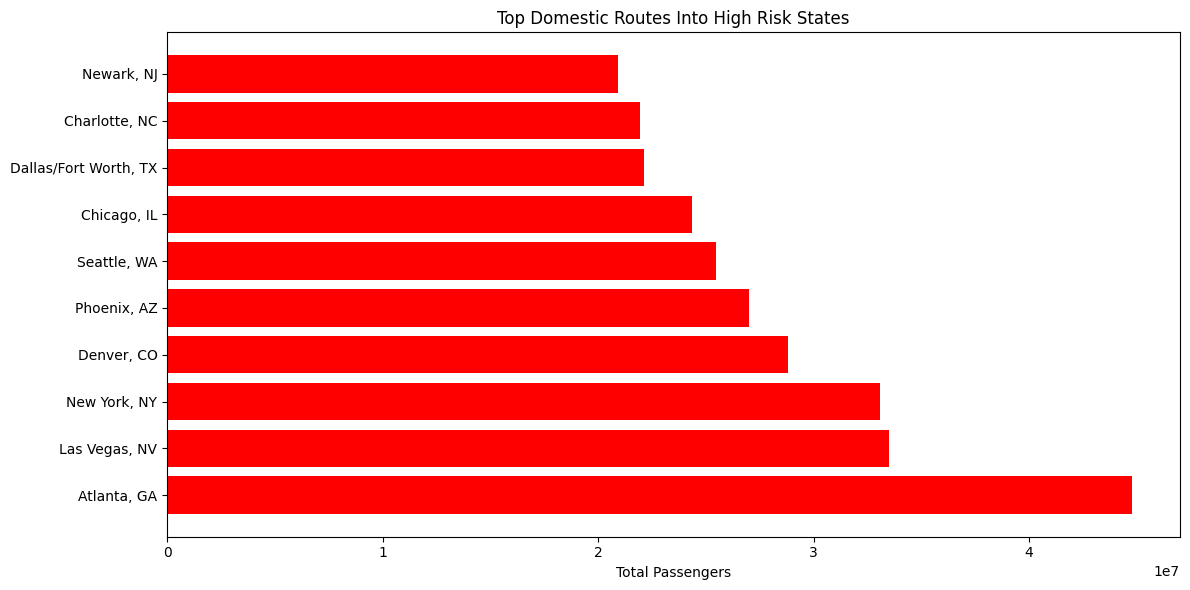

In [0]:
import matplotlib.pyplot as plt

# Chart 1 - Top Routes Into High Risk States
top_routes_chart = domestic_df_clean.groupby(
    ['ORIGIN_CITY_NAME', 'DEST_STATE_NM']
)['PASSENGERS'].sum().reset_index()

top_routes_chart = top_routes_chart.sort_values(
    'PASSENGERS', ascending=False
).head(10)

plt.figure(figsize=(12,6))
plt.barh(
    top_routes_chart['ORIGIN_CITY_NAME'],
    top_routes_chart['PASSENGERS'],
    color='red'
)
plt.title('Top Domestic Routes Into High Risk States')
plt.xlabel('Total Passengers')
plt.tight_layout()
plt.show()

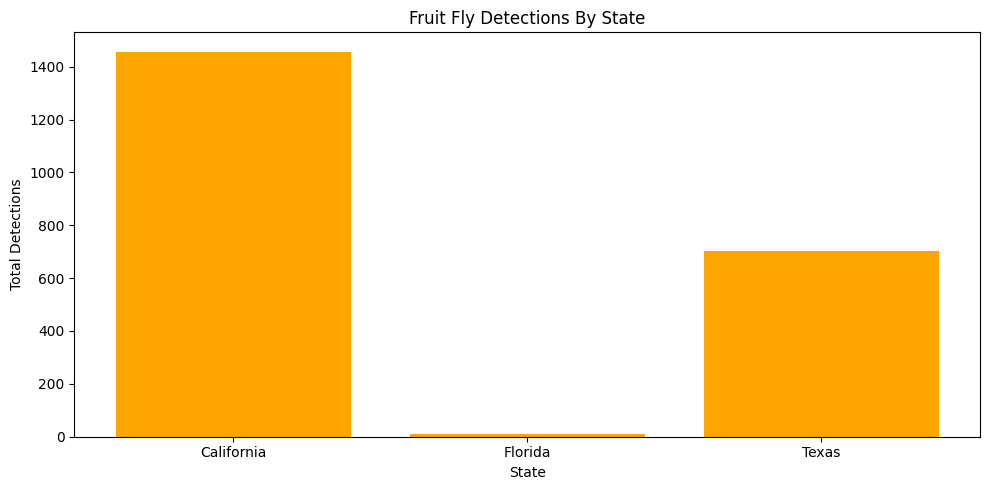

In [0]:
# Chart 2 - Detections By State
state_detections = detections_df.groupby(
    'STATE_NAME'
)['Count_'].sum().reset_index()

plt.figure(figsize=(10,5))
plt.bar(
    state_detections['STATE_NAME'],
    state_detections['Count_'],
    color='orange'
)
plt.title('Fruit Fly Detections By State')
plt.xlabel('State')
plt.ylabel('Total Detections')
plt.tight_layout()
plt.show()

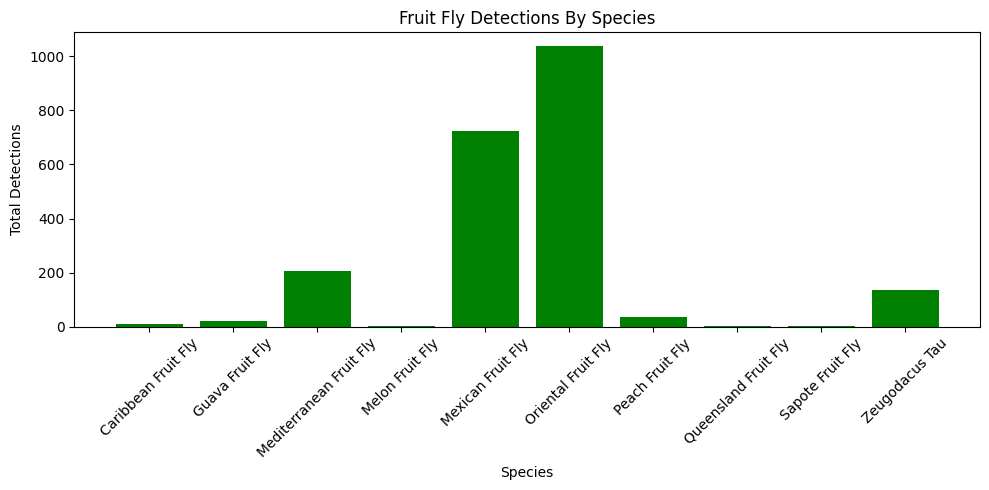

In [0]:
# Chart 3 - Detections By Species
species_chart = detections_df.groupby(
    'CommonName'
)['Count_'].sum().reset_index()

plt.figure(figsize=(10,5))
plt.bar(
    species_chart['CommonName'],
    species_chart['Count_'],
    color='green'
)
plt.title('Fruit Fly Detections By Species')
plt.xlabel('Species')
plt.ylabel('Total Detections')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()